In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("billionaire_individual_2026.csv")
print(df.head())


   rank      person_name gender   age        country iso3 wb_country_name  \
0     1        Elon Musk      M  54.0  United States  USA   United States   
1     2       Larry Page      M  53.0  United States  USA   United States   
2     3       Jeff Bezos      M  62.0  United States  USA   United States   
3     4      Sergey Brin      M  52.0  United States  USA   United States   
4     5  Mark Zuckerberg      M  41.0  United States  USA   United States   

        state       city  net_worth_usd_m  ...  wealth_gdp_ratio_pct  \
0       Texas     Austin        800629.06  ...              2.784704   
1  California  Palo Alto        260898.20  ...              0.907442   
2     Florida      Miami        248778.91  ...              0.865289   
3  California  Los Altos        240743.24  ...              0.837340   
4  California  Palo Alto        216089.31  ...              0.751590   

  wealth_per_citizen_usd wealth_country_share_pct sector_dominance_score  \
0              2354.0229    

In [3]:
columns = df.columns
print(columns)

rows = df.shape[0]
print(rows)


df_clean = df[[
    "person_name",
    "age",
    "net_worth_usd_m",
    "primary_industry",
    "industries",
    "country",
    # "city",
    "gender"
]]

df_clean = df_clean.rename(columns={
    "person_name": "name",
    "net_worth_usd_m": "net_worth_million_usd",
    "primary_industry": "industry"
})



print(df_clean.head())
df_clean.to_csv("billionaire_individual_needed_columns.csv", index=False)

Index(['rank', 'person_name', 'gender', 'age', 'country', 'iso3',
       'wb_country_name', 'state', 'city', 'net_worth_usd_m', 'net_worth_usd',
       'source_of_wealth', 'industries', 'primary_industry', 'self_made',
       'wealth_gdp_ratio_pct', 'wealth_per_citizen_usd',
       'wealth_country_share_pct', 'sector_dominance_score', 'gdp_usd',
       'population', 'gdp_year', 'forbes_uri', 'scrape_timestamp',
       'birth_year'],
      dtype='object')
3384
              name   age  net_worth_million_usd    industry  industries  \
0        Elon Musk  54.0              800629.06  Technology  Technology   
1       Larry Page  53.0              260898.20  Technology  Technology   
2       Jeff Bezos  62.0              248778.91  Technology  Technology   
3      Sergey Brin  52.0              240743.24  Technology  Technology   
4  Mark Zuckerberg  41.0              216089.31  Technology  Technology   

         country gender  
0  United States      M  
1  United States      M  
2  Unit

In [4]:
df_needed = pd.read_csv("billionaire_individual_needed_columns.csv")

print(f"number of columns: {len(df_needed.columns)}, name of columns: {df_needed.columns}")  

df_needed.head()

number of columns: 7, name of columns: Index(['name', 'age', 'net_worth_million_usd', 'industry', 'industries',
       'country', 'gender'],
      dtype='object')


,name,age,net_worth_million_usd,industry,industries,country,gender
0,Elon Musk,54.0,800629.06,Technology,Technology,United States,M
1,Larry Page,53.0,260898.20,Technology,Technology,United States,M
2,Jeff Bezos,62.0,248778.91,Technology,Technology,United States,M
3,Sergey Brin,52.0,240743.24,Technology,Technology,United States,M
4,Mark Zuckerberg,41.0,216089.31,Technology,Technology,United States,M


Average age: 65.3


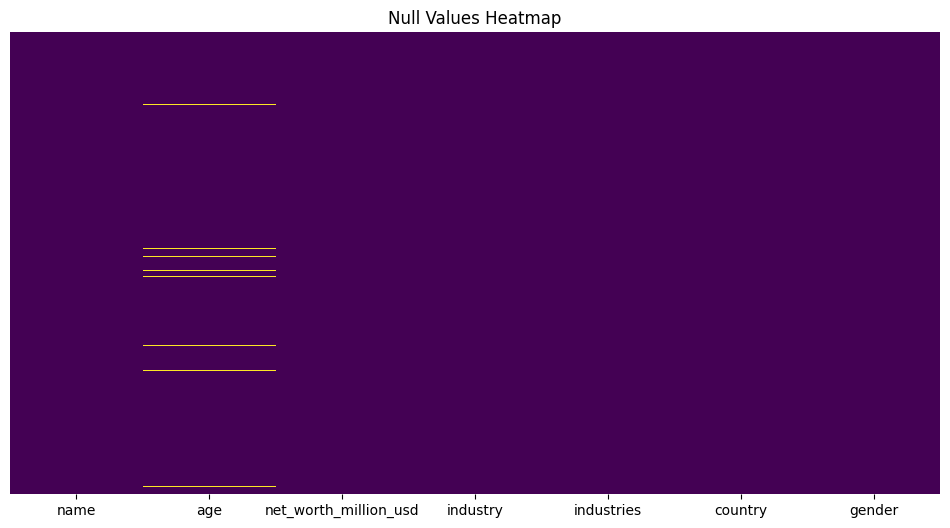

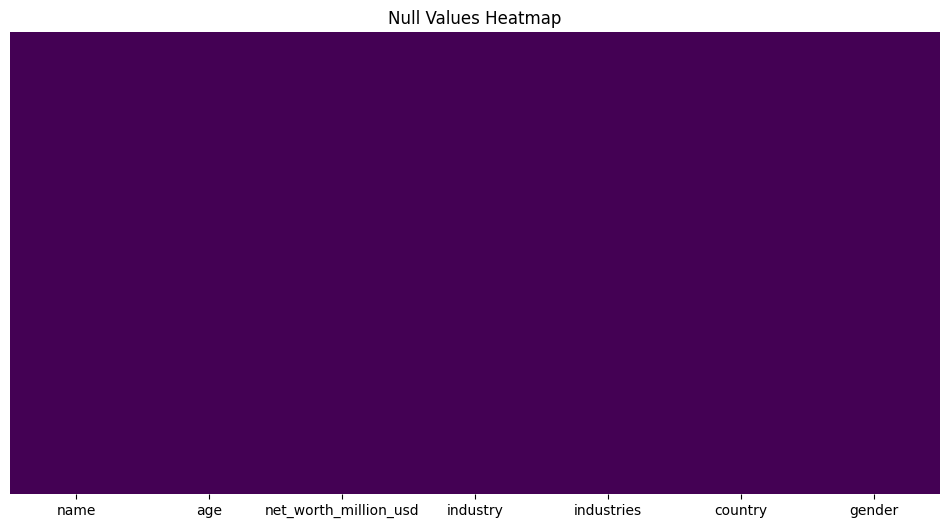

np.int64(0)

In [5]:
avg_age = round(df_needed["age"].mean() ,1)

print(f"Average age: {avg_age}")

plt.figure(figsize=(12, 6))
sns.heatmap(df_needed.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Null Values Heatmap")
plt.show()

df_needed["age"] = df_needed["age"].fillna(df_needed["age"].mean())

plt.figure(figsize=(12, 6))
sns.heatmap(df_needed.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Null Values Heatmap")
plt.show()


df_needed["age"].isnull().sum()


In [7]:
df_needed.head()

df_needed = df_needed[[
    "name",
    "age",
    "net_worth_million_usd",
    # "primary_industry",
    "industries",
    "country"
    # "city",
    # "gender"
]]


df_needed.sample(n=5)

,name,age,net_worth_million_usd,industries,country
1700,Huang Zelan & family,70.0,2435.27,Metals & Mining,China
790,Arkady Rotenberg,74.0,5290.53,Construction & Engineering,Russia
1280,Jay Paul,78.0,3267.01,Real Estate,United States
2904,Christoph Zeller,68.0,1286.53,Healthcare,Liechtenstein
113,Diane Hendricks,79.0,22332.90,Construction & Engineering,United States


In [10]:
# now let's remove billionaires with net worth less than 1 billion USD

df_needed.info()

df_needed = df_needed[df_needed["net_worth_million_usd"] >= 1000]

df_needed.info()


3384-3374

<class 'pandas.core.frame.DataFrame'>
Index: 3374 entries, 0 to 3373
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   3374 non-null   object 
 1   age                    3374 non-null   float64
 2   net_worth_million_usd  3374 non-null   float64
 3   industries             3374 non-null   object 
 4   country                3374 non-null   object 
dtypes: float64(2), object(3)
memory usage: 158.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3374 entries, 0 to 3373
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   3374 non-null   object 
 1   age                    3374 non-null   float64
 2   net_worth_million_usd  3374 non-null   float64
 3   industries             3374 non-null   object 
 4   country                3374 non-null   object 
dtypes: float64(

10

In [14]:


df_needed["age"] = df_needed["age"].astype(int)

# df_needed["net_worth_million_usd"] = df_needed["net_worth_million_usd"].astype(int)

df_needed.info()

df_needed.sample(n=5)

<class 'pandas.core.frame.DataFrame'>
Index: 3374 entries, 0 to 3373
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   3374 non-null   object 
 1   age                    3374 non-null   int64  
 2   net_worth_million_usd  3374 non-null   float64
 3   industries             3374 non-null   object 
 4   country                3374 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 158.2+ KB


,name,age,net_worth_million_usd,industries,country
1525,Nandan Nilekani,70,2745.53,Technology,India
1108,Ben Lamm,44,3853.97,Technology,United States
2653,Lu Lili,65,1463.45,Technology,China
2051,Jitendra Virwani,60,2016.15,Real Estate,India
687,William Goldring & family,83,6000.00,Food & Beverage,United States


In [15]:
df_needed.to_csv("billionaire_individual_perfect.csv", index=False)


In [18]:
print(df_needed["name"].sample(n=30)          ) 

66                        Abigail Johnson
3347                    Li Liufa & family
2014                          Ajay Parekh
2125                        Gerda Tschira
2436                   Franziska Wuerbser
2766                       Zhang Wenzhong
1853    Cynthia Helena Grossman Fleishman
1964         Athanasios Martinos & family
3258                     Andrii Verevskyi
241                           Andrew Beal
2935                         Wang Baoqing
1467                      Stephen Deckoff
2146                Sun Mengquan & family
3333                      Clemens Fischer
274                       Tilman Fertitta
2024                       Randal J. Kirk
2994                      Kenzo Tsujimoto
382                         Eric Wittouck
1787                       Edward Lampert
1194                   William Wrigley Jr
414       Alexandra Schoerghuber & family
1927                          Lyu Yixiong
722                            Carl Thoma
2283                          JB S